# External Background Sensitivity tests

## Purpose

Having determined and validated robust background and ICGC corrections in the previous notebook [06_ext_contaminant_ICGC_corrections](Coma_CSS_color/06_ext_contaminant_ICGC_corrections.ipynb) we now need to ask the question...

>How do the inner, annulus, and inner–environment diagnostics change when independently calibrated fg/bg and ICGC components are applied?

## Motivation

What we are aiming for here is not to maximize significance, but to test the sensitivity to the external corrections.

## Outline

We'll do this in layers:

1. No external correction — your current clean baseline.
2. Subtract fg/bg only.
3. Subtract fg/bg + constant ICGC baseline.
4. Compare the resulting:

$$ \langle P_{\rm blue}\rangle_{\rm inner}, \quad \langle P_{\rm blue}\rangle_{\rm annulus}, \quad \Delta P_{\rm IE}. $$

5. Re-run the environmental correlations for each version.
6. Then do a modest sensitivity grid on:
   - ICGC normalization,
   - ICGC Pblue,
   - fg/bg Pblue.

The key aim is to see whether the physical picture survives reasonable external corrections.


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Tuple, Optional, Dict
from tqdm.auto import tqdm

import ast
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.stats import rayleightest
from scipy.stats import binomtest, ks_2samp, chi2, spearmanr,  pearsonr, linregress
from shapely.geometry import Polygon, Point
import logging

from src.config import (
    Columns,
    BCG,
    AnalysisConfig,
    ClusterCenter,
)

RNG_SEED = 20260830
rng = np.random.default_rng(RNG_SEED)

N_PERM = 1000   # development run

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# logging function

def setup_logging(verbose=False, name = "Coma_GCs_debug"):
    """
    Call this once at the top of the notebook.
    If verbose=True, DEBUG messages will show; otherwise only INFO+.
    """    
    # Remove any root handlers (if I had root-level logging before)
    for h in logging.root.handlers[:]:
        logging.root.removeHandler(h)

    # Get named logger and clear *its* handlers + disable propagation
    logger = logging.getLogger(name)
    for h in logger.handlers[:]:
        logger.removeHandler(h)
    logger.propagate = False

    # Set logger’s level
    logger.setLevel(logging.DEBUG)   # we capture everything here

    # INFO-only handler (no timestamp)
    info_handler = logging.StreamHandler()
    info_handler.setLevel(logging.INFO)
    info_handler.addFilter(lambda rec: rec.levelno == logging.INFO)
    info_handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(info_handler)

    # non-INFO handler (timestamped, DEBUG or WARNING+)
    other = logging.StreamHandler()
    other.setLevel(logging.DEBUG if verbose else logging.WARNING)
    other.addFilter(lambda rec: rec.levelno != logging.INFO)
    # allow only your logger’s DEBUG (if you still want a name-filter):
    other.addFilter(lambda rec: rec.levelno != logging.DEBUG or rec.name == name)
    fmt = "[%(levelname)s] %(asctime)s.%(msecs)03d %(message)s"
    other.setFormatter(logging.Formatter(fmt, datefmt="%H:%M:%S"))
    logger.addHandler(other)


In [3]:
# Set verbosity here:
name = "ext_contaminant_and_icgc_sensitivity"
setup_logging(verbose=True, name = name)   # or False

# testing logging
logger = logging.getLogger(name)
logger.debug("Debug messages are ON")
logger.info("Info messages are always shown")
logger.warning("Warnings also show up")


[DEBUG] 13:53:03.412 Debug messages are ON
Info messages are always shown
[WARNING] 13:53:03.414 Warnings also show up


# Initialization

## Load in galaxies

Load in a `csv` file, which has been produced from manual and online archives, and saved in `Coma_Gal_List_Create.ipynb`, so this can be used in the calculation and plotting routines.

A second file of more data from the SIMBAD and NED archives has bee extracted, but this has indeterminate or somewhat inconsistent effective radii.

Select using `archive = True` or `False` if "manual" data is preferred.


In [4]:
def prep_gal_shapes(gals_df: pd.DataFrame) -> pd.DataFrame:
    g = gals_df.copy()

    # Convert minor axis from arcmin -> arcsec when present
    # (Your 'galdim_minaxis' is arcmin per your note)
    g["minor_axis_arcsec"] = np.where(
        np.isfinite(g["galdim_minaxis"]),
        g["galdim_minaxis"].astype(float) * 60.0,
        np.nan
    )

    # Axis ratio q=b/a using available axes (ratio is robust to diameter vs semi-axis ambiguity)
    a = g["major_axis_arcsec"].astype(float)
    b = g["minor_axis_arcsec"].astype(float)

    q = b / a
    # Clip to sane range; if missing, default to circular
    g["q_axis"] = np.where(np.isfinite(q), np.clip(q, 0.2, 1.0), 1.0)

    # Clean PA; if missing, set 0 (ellipse aligned N-S; effect minimal for q~1)
    g["pa_deg"] = pd.to_numeric(g["galdim_angle"], errors="coerce").fillna(0.0)

    return g


In [5]:
archive = True
if archive:
    logger.warning('NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors')
    # Load in the file of galaxy data extracted from archives OR 
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_from_archives.csv')
    gals_df_from_csv = gals_df.copy()
    gals_df = prep_gal_shapes(gals_df)
else:
    logger.warning('NOTE: Loading manual data for Coma cluster galaxies')
    # Load in the file of sanitised and augmented galaxy data  
    gals_df = pd.read_csv('../Coma_LSD_CSS/data/gals_data_cleaned.csv')
gals_df.tail(5)

[WARNING] 13:53:22.702 NOTE: Loading SIMBAD / NED extracted data for Coma cluster galaxies - NOTE. With colors


,name,ra,dec,otype,z,Vmag_simbad_raw,Bmag_simbad_raw,BV_simbad_raw,gmag_simbad_raw,rmag_simbad_raw,...,Re_GCS_scale,Re_GCS_arcsec,n_gcs_prior,n_gcs_red_prior,n_gcs_blue_prior,gal_color,gal_color_src,minor_axis_arcsec,q_axis,pa_deg
169,NGC 4874,194.898789,27.959248,LIN,0.023910,12.71,13.7,0.990000,12.6472,11.7979,...,4.8,142.014382,NaN,NaN,NaN,1.254257,g-i,135.64440,0.966099,63.0
170,NGC 4869,194.847328,27.911592,EmG,0.022879,13.52,14.9,1.379999,14.4290,13.6240,...,3.2,23.865957,NaN,NaN,NaN,1.230054,g-i,41.45118,0.834300,47.0
171,NGC 4889,195.033738,27.977025,EmG,0.021500,11.30,13.0,1.700000,12.3528,11.5017,...,4.8,110.525917,NaN,NaN,NaN,1.033334,g-i,109.01400,0.621500,75.0
172,SDSS J130042.56+280658.6,195.177360,28.116320,LSB,0.020701,18.24,NaN,NaN,17.6480,17.0110,...,3.2,33.052243,NaN,NaN,NaN,0.868321,g-i,19.49800,1.000000,0.0
173,Coma cluster,195.017071,27.977025,CLUSTER,0.021500,NaN,NaN,NaN,NaN,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0


In [6]:
# Test the load
gal1=['IC 4051','NGC 4883','NGC 4876']
for gal_i in gal1:
    gal_row = gals_df.loc[gals_df['name'] == gal_i].iloc[0]
    print(f"{gal_i}: mv={gal_row['mV_app']:4.2f} mag, MV={gal_row['MV_abs']:5.2f} mag")


IC 4051: mv=13.34 mag, MV=-21.66 mag
NGC 4883: mv=14.34 mag, MV=-20.66 mag
NGC 4876: mv=14.49 mag, MV=-20.51 mag


In [7]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

## Load CSS candidates

Now we have galaxy data, we need to load up the CSS candidate file. 

In [8]:
#inFileName = "allpointings_master.dat_NoOverlap"
# inFileName = "data/newallpointingsmaster_26may2021.dat"  # with delimeter ' '
inFileName = "data/inspectedpointings_merged_19Oct2024.csv"  # with delimieter ','

inFile = open(inFileName, 'r')
lines = inFile.readlines()
inFile.close

data = pd.read_csv(inFileName, delimiter=',')


and then we need to filter for color on CSS in general, and additional filter for UCDs on the tighter color range and luminosity, and outlined in paper 1. Color value are 

- CSS: *color* 0.5 < (F475W − F814W ) < 2.5 and 
- UCD: *color* 1.3 < (F475W − F814W ) < 2.1 and *magnitude* F814W < 22.9 mag


In [9]:
data = data[(data['color'] > 0.5) & (data['color'] < 2.5)]
data_bright = data.loc[data['mag_814']<=25.0].copy()  # take a cut of data where completeness is > ~90% 

# Define the range for UCD 'color' and 'mag_814'
ucd_color_min, ucd_color_max = 1.3, 2.1     #
ucd_mag_814_min, ucd_mag_814_max = 0, 22.9  # should be 0 mag to 22.9 mag

# remove duplicated data
data = data.drop_duplicates()

# Filter the DataFrame
gcs_df = data[(data['color'] <= ucd_color_min) | (data['color'] >= ucd_color_max) |
                 (data['mag_814'] <= ucd_mag_814_min) | (data['mag_814'] >= ucd_mag_814_max)]
ucd_df = data[(data['color'] > ucd_color_min) & (data['color'] < ucd_color_max) &
                 (data['mag_814'] > ucd_mag_814_min) & (data['mag_814'] < ucd_mag_814_max)]


In [10]:
total_gcs = len(gcs_df)
total_ucds = len(ucd_df)
total_css = len(data)
total_bright = len(data_bright)

print('Total GCs: ', total_gcs)
print('Total UCDs: ', total_ucds)
print('Total count: ', total_css)
print('Total bright (F814W ≤ 25.0 mag): ', total_bright)
print('Mag F814W min, max:', np.min(data['mag_814']), np.max(data['mag_814']) )
print('Mag F475W min, max:', np.min(data['mag_475']), np.max(data['mag_475']) )

data.head(5)

Total GCs:  22104
Total UCDs:  523
Total count:  22627
Total bright (F814W ≤ 25.0 mag):  10304
Mag F814W min, max: 16.66917944 29.0727298
Mag F475W min, max: 18.59635274 31.0122151


,x_wcs,y_wcs,flux_814,flux_475,mag_814,mag_475,color,pointing,x,y,type,x_wcs_f,y_wcs_f,gc_type_f,pointing_f,Unnamed: 15
0,194.09794,27.244074,0.458373,0.203884,26.152547,27.681062,1.528516,OS21,708.977,3994.384,gc,194.09794,27.244074,gc,OS21,NaN
1,194.09828,27.212645,1.207550,1.165456,25.100832,25.788280,0.687449,OS21,2964.827,4170.375,gc,194.09828,27.212645,gc,OS21,NaN
3,194.09916,27.222516,4.788598,2.630347,23.605074,24.904488,1.299414,OS21,2261.617,4052.017,gc,194.09916,27.222516,gc,OS21,NaN
4,194.09917,27.213105,4.268017,1.134324,23.730029,25.817677,2.087648,OS21,2937.748,4109.924,gc,194.09917,27.213105,gc,OS21,NaN
5,194.09971,27.207500,2.269763,2.564432,24.415643,24.932042,0.516399,OS21,3342.696,4111.336,gc,194.09971,27.207500,gc,OS21,NaN


In [11]:
data.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15'],
      dtype='str')

## Load and verify the metrics quantities

In [12]:
metrics_df = pd.read_csv(
    "../Coma_CSS_color/data/metrics_df_fiducial_orig_recal.csv"
)

PB_METRIC = "Delta_Pblue_mean_bgsub"
COLOR_METRIC = "Delta_mean_color_bgsub"

required = [
    "mean_color",
    "mean_color_bgsub",
    COLOR_METRIC,
    PB_METRIC,
]

for col in required:
    print(f"{col:30s}", col in metrics_df.columns)



mean_color                     True
mean_color_bgsub               True
Delta_mean_color_bgsub         True
Delta_Pblue_mean_bgsub         True


## Check environmental metrics and baseline


In [13]:
sub = metrics_df[
    ["Delta_Pblue_mean_bgsub",
     "gc_bg_voronoi_density_arcsec2_inv"]
].dropna()

rho_obs, p_obs = spearmanr(
    sub["Delta_Pblue_mean_bgsub"],
    sub["gc_bg_voronoi_density_arcsec2_inv"]
)

print(rho_obs, p_obs)

-0.4420041180507892 9.183121292985238e-06


In [14]:
RHO_OBS = rho_obs
P_OBS   = p_obs

# Add $P_\mathrm{blue}$ to CSS data

In [15]:
# import numpy as np
# from typing import Tuple, Optional, Callable

# def _normal_pdf(x: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
#     """Vectorized Normal PDF."""
#     x = np.asarray(x, dtype=float)
#     mu = np.asarray(mu, dtype=float)
#     sigma = np.asarray(sigma, dtype=float)
#     return np.exp(-0.5 * ((x - mu) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)

# # These were the submitted parameters for paper three, but I found an indexing error (see. Coma_Gal_Color_CMD.ipynb)
# #
#     # gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#     #     (1.58, 0.30, 1.76, 0.19, 0.54),  # 23-24
#     #     (1.51, 0.15, 1.68, 0.23, 0.59),  # 24-25
#     #     (1.46, 0.18, 1.67, 0.25, 0.55),  # 25-26
#     #     (1.40, 0.22, 1.64, 0.28, 0.57),  # 26-27
#     # ),

# def compute_Pblue(
#     mag814: np.ndarray,
#     color: np.ndarray,
#     *,
#     bright_mag_cut: float = 23.0,
#     # mag-binned mixture model for >= bright_mag_cut
#     mag_edges: Tuple[float, ...] = (23.0, 24.0, 25.0, 26.0, 27.0),
#     # These are the 'recalibrated values'
#     gmm_params: Tuple[Tuple[float, float, float, float, float], ...] = (
#         (1.521, 0.162, 1.707, 0.229, 0.56),  # 23-24
#         (1.457, 0.176, 1.668, 0.246, 0.58),  # 24-25
#         (1.399, 0.224, 1.641, 0.282, 0.57),  # 25-26
#         (1.217, 0.183, 1.596, 0.291, 0.45),  # 26-27
#     ),
#     # faint handling
#     faint_mode: str = "extend",   # "extend" or "clamp"
#     faint_max_edge: float = 28.0, # used only if extend
#     # optional prior modifier (later): fb(R) model
#     # If provided, pass an array fb of shape (N,) OR provide fb_func(r) separately.
#     fb: Optional[np.ndarray] = None,
# ) -> Tuple[np.ndarray, np.ndarray]:
#     """
#     Compute P(blue | color, mag) under a mag-binned 2-Gaussian mixture.

#     Returns:
#       Pblue (N,) float array
#       mag_bin_id (N,) int array (bright regime -> -1)
#     """
#     mag814 = np.asarray(mag814, dtype=float)
#     color = np.asarray(color, dtype=float)
#     if mag814.shape != color.shape:
#         raise ValueError("mag814 and color must have the same shape.")

#     N = mag814.size
#     Pblue = np.full(N, np.nan, dtype=float)
#     mag_bin_id = np.full(N, -1, dtype=int)

#     # Bright regime: undefined for bimodality by construction
#     bright = mag814 < bright_mag_cut
#     mid_or_faint = ~bright

#     # Prepare edges/params with faint handling
#     edges = np.asarray(mag_edges, dtype=float)
#     if faint_mode not in ("extend", "clamp"):
#         raise ValueError('faint_mode must be either "extend" or "clamp".')
#     params = np.array(gmm_params, dtype=float)
#     nbins = edges.size - 1
#     if params.shape[0] != nbins:
#         raise ValueError("gmm_params length must match len(mag_edges)-1.")

#     if faint_mode == "extend":
#         if faint_max_edge <= edges[-1]:
#             raise ValueError("faint_max_edge must be > mag_edges[-1] when extend.")
#         edges = np.concatenate([edges, [float(faint_max_edge)]])
#         params = np.vstack([params, params[-1:]])
#         nbins = edges.size - 1

#     if np.any(mid_or_faint):
#         m = mag814[mid_or_faint]
#         c = color[mid_or_faint]

#         bin_id = np.digitize(m, edges) - 1
#         bin_id = np.clip(bin_id, 0, nbins - 1)

#         mu_b = params[bin_id, 0]
#         sg_b = params[bin_id, 1]
#         mu_r = params[bin_id, 2]
#         sg_r = params[bin_id, 3]
#         w_b  = params[bin_id, 4]

#         # Likelihood terms
#         pb = w_b * _normal_pdf(c, mu_b, sg_b)
#         pr = (1.0 - w_b) * _normal_pdf(c, mu_r, sg_r)

#         # Optional prior modifier (later): replace w_b -> fb*w_b and (1-w_b)->(1-fb)*(1-w_b)?
#         # For now, if fb is provided, treat it as a multiplicative reweighting of the mixture prior:
#         if fb is not None:
#             fb_arr = np.asarray(fb, dtype=float)
#             if fb_arr.shape != mag814.shape:
#                 raise ValueError("fb must have the same shape as mag814/color if provided.")
#             fb_sub = fb_arr[mid_or_faint]
#             pb = fb_sub * pb
#             pr = (1.0 - fb_sub) * pr

#         denom = pb + pr
#         # Safe division
#         p = np.divide(pb, denom, out=np.full_like(pb, np.nan), where=denom > 0)

#         Pblue[mid_or_faint] = p
#         mag_bin_id[mid_or_faint] = bin_id

#     return Pblue, mag_bin_id


In [16]:
# Add in blue probability (based on magnitude and color of GCs)
# NOTE: The compute_Pblue function was originally below, but moved above as needs executing before 
# running this cell.

from src.color_metrics import compute_Pblue

Pblue_all, mag_bin_id = compute_Pblue(
    mag814=data["mag_814"].values,
    color=data["color"].values
)

data = data.copy()
data["Pblue"] = Pblue_all


## Check columns

In [26]:
keywords = [
    "Pblue",
    "_eff"
]

for keyword in keywords:
    matches = [
        c for c in metrics_df
        if keyword.lower() in c.lower()
    ]

    print(f"\n{keyword}:")
    print(matches)




Pblue:
['N_inner_Pblue', 'N_annulus_Pblue', 'matched_color_Pblue_samples', 'Pblue_mean_inner_raw', 'Pblue_mean_annulus', 'N_eff_bgsub_Pblue', 'N_geom_bgsub_Pblue', 'sum_Pblue_inner', 'sum_Pblue_annulus', 'Pblue_std_inner', 'Pblue_std_annulus', 'Pblue_inner_meets_min', 'Pblue_annulus_nonzero', 'min_gc_for_Pblue', 'Pblue_mean', 'Pblue_mean_err', 'Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom', 'Pblue_mean_exp', 'Delta_Pblue_mean', 'Pblue_mean_bgsub_exp', 'Delta_Pblue_mean_bgsub', 'Pblue_mean_bgsub_geom_exp', 'Delta_Pblue_mean_bgsub_geom']

_eff:
['A_ap_eff', 'A_bg_eff', 'A_ap_eff_over_geom', 'A_bg_eff_over_geom', 'alpha_eff', 'N_eff_bgsub_color', 'N_eff_bgsub_Pblue']


# Build cut-down routines

In [18]:
perm_data = data.copy().reset_index(drop=True)
perm_data["_perm_idx"] = np.arange(len(perm_data), dtype=int)

pblue_orig = perm_data["Pblue"].to_numpy(dtype=float)

In [19]:

def select_gc_samples_for_galaxy(
    data,
    gal_row,
    cols,
    kRe_inner=8.0,
    kRe_outer=(12.0, 20.0),
):
    """
    Returns inner and annulus GC samples for one galaxy.
    """
    kRe = elliptical_radius_kRe(
        data[cols.gc_ra].values,
        data[cols.gc_dec].values,
        gal_row[cols.gal_ra],
        gal_row[cols.gal_dec],
        gal_row[cols.gal_Re_arcsec],
        gal_row["q_axis"],
        gal_row["pa_deg"],
    )

    data = data.copy()
    data["kRe"] = kRe

    inner = data[kRe <= kRe_inner]
    ann = data[(kRe > kRe_outer[0]) & (kRe <= kRe_outer[1])]

    return inner, ann

def elliptical_radius_kRe(
    gc_ra, gc_dec,
    gal_ra, gal_dec,
    Re_arcsec,
    q_axis,
    pa_deg,
):
    """
    Compute elliptical radius in units of Re for each GC relative to a galaxy.
    PA assumed East of North (SIMBAD convention).
    """
    # SkyCoord objects
    gc = SkyCoord(gc_ra * u.deg, gc_dec * u.deg)
    gal = SkyCoord(gal_ra * u.deg, gal_dec * u.deg)

    # Tangent-plane offsets (arcsec)
    dra = (gc.ra - gal.ra).to(u.arcsec).value * np.cos(gal.dec.to(u.rad).value)
    ddec = (gc.dec - gal.dec).to(u.arcsec).value

    # Rotate into galaxy frame
    pa = np.deg2rad(pa_deg)
    x =  dra * np.cos(pa) + ddec * np.sin(pa)
    y = -dra * np.sin(pa) + ddec * np.cos(pa)

    # Elliptical radius (arcsec)
    r_ell = np.sqrt(x**2 + (y / q_axis)**2)

    # Return in units of Re
    return r_ell / Re_arcsec

## Build the membership cache once

In [20]:
@dataclass
class Columns:
    # galaxy table columns
    gal_id: str = "name"
    gal_ra: str = "ra"
    gal_dec: str = "dec"
    gal_Re_arcsec: str = "Re_best_arcsec"
    gal_MV: str = "MV_abs"

    # GC table columns
    gc_ra: str = "x_wcs"
    gc_dec: str = "y_wcs"
    gc_color: str = "color"           # e.g., F475W-F814W
    gc_mag: Optional[str] = "mag_814"  # optional
    gc_host: Optional[str] = "gal_id"  # if we already have assignment

@dataclass
class AnalysisConfig:
    aperture_Re: float = 8.0
    # optional background annulus for "local GC density"
    bg_annulus_inner_Re: float = 12.0
    bg_annulus_outer_Re: float = 20.0

    # bootstrap
    n_boot: int = 300
    min_gc_for_gmm: int = 30  # below this, we can fall back to median-only
    min_gc_for_Pblue: int = 10
    # baseline fit
    huber_eps: float = 1.35   # robust regression tuning


In [21]:
galaxy_cache = {}

cols = Columns
cfg = AnalysisConfig

for _, gal in tqdm(
    gals_df.iterrows(),
    total=len(gals_df),
    desc="Caching aperture membership"
):
    inner, ann = select_gc_samples_for_galaxy(
        perm_data,
        gal,
        cols,
        kRe_inner=cfg.aperture_Re,
        kRe_outer=(
            cfg.bg_annulus_inner_Re,
            cfg.bg_annulus_outer_Re,
        ),
    )

    # Use EXACTLY the same eligibility mask as the current
    # Pblue calculation in compute_metrics_for_galaxy.
    inner_mask = np.isfinite(inner["color"].to_numpy(dtype=float)) & np.isfinite(inner["Pblue"].to_numpy(dtype=float))
    ann_mask = np.isfinite(ann["color"].to_numpy(dtype=float)) & np.isfinite(ann["Pblue"].to_numpy(dtype=float))

    inner_idx = inner.loc[inner_mask, "_perm_idx"].to_numpy(dtype=int)
    ann_idx   = ann.loc[ann_mask, "_perm_idx"].to_numpy(dtype=int)

    gal_id = gal[cols.gal_id]

    galaxy_cache[gal_id] = {
        "inner_idx": inner_idx,
        "ann_idx": ann_idx,
    }  


Caching aperture membership:   0%|          | 0/174 [00:00<?, ?it/s]

## Pull fixed baseline metrics

In [22]:
metrics_df["Delta_P_IE"] = (
    metrics_df["Pblue_mean_inner_raw"]
    - metrics_df["Pblue_mean_annulus"]
)

fixed_metrics = (
    metrics_df
    .set_index(cols.gal_id)
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/4244759424.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["Delta_P_IE"] = (


In [23]:
science_ids = fixed_metrics.index[
    np.isfinite(fixed_metrics["Delta_Pblue_mean_bgsub"])
]
len(science_ids)

93

In [24]:
fixed_metrics["r_bg"] = (
    fixed_metrics["alpha_eff"]
    * fixed_metrics["N_annulus_Pblue"]
    / fixed_metrics["N_inner_Pblue"]
)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/3521669378.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fixed_metrics["r_bg"] = (


# Photometric-system check:
Peng et al. (2011) report F475W–F814W colors on the AB system, whereas the zeropoints adopted by Madrid et al. correspond approximately to the ACS VEGAMAG system. The difference in F475W–F814W color zeropoint is approximately 0.50 mag. Transforming the Peng outer-GC peaks from 0.89 and 1.22 gives approximately 1.39 and 1.72 in the Madrid color system, in excellent agreement with the empirical $R>130$ kpc distribution recovered here.

This is in comparison to Figure 8 from Peng+2011 (below) - from which they note the color distribution of all GCs shows the typical bimodality seen in
extragalactic GC systems, displaying a prominent peak of blue (metal-poor) GCs with $(g − I ) \approx 0.9$ and a red (metal-rich)
peak with $(g − I ) \approx 1.15$

## Convert color / magnitude cuts

Using Peng+2011 calibration for the background and ICGC, first requires us to adjust from AB system to VEGAMAG (which we use in our data) as the zeropoints are different. So both the color and the magnitude cuts need translating as the Madrid+2018 catalog is using those different ACS zeropoints.

Peng+2011 notes...

> Photometry was put on the AB magnitude system using the zero points of Sirianni et al. (2005). All magnitudes in this paper are AB unless otherwise specified, and

and Madrid+2018 specifies...

> Photometric zero-points are obtained from the updated ACS zero-point tables maintained on the STScI website; we use ZPF475W = 26.131 mag and ZPF814W = 25.504 mag.

So, using the zeropoints identified from the literature, i.e., for the same measured count rate:

$$ m_{\rm Madrid}=m_{\rm Peng,AB}+(ZP_{\rm Madrid}-ZP_{\rm Peng,AB}). $$

For F814W,

$$ 25.504-25.937=-0.433, $$

so Peng's magnitude limits translate approximately to:

$$ I_{\rm Peng}<26.5 \quad\Rightarrow\quad m_{814,\rm Madrid}<26.07, $$

and their Figure 8 bright sample

$$ I_{\rm Peng}<25 \quad\Rightarrow\quad m_{814,\rm Madrid}<24.57. $$

For the color, we found

$$ (g-I)_{\rm Madrid} \simeq (g-I)_{\rm Peng}+0.496. $$

Therefore their GC-candidate color cut

$$ 0.6<(g-I)_{\rm Peng}<1.5 $$

becomes approximately

$$\boxed{1.10<(F475W−F814W)_\mathrm{Madrid} <2.00}.$$

# Set Peng+2011 initial config values



In [30]:
PENG_BG_DENSITY = 2.8       # arcmin^-2
PENG_BG_DENSITY_ERR = 0.3   # arcmin^-2

PENG_ICGC_FBLUE = 0.80
PENG_ICGC_FRED  = 0.20

PENG_ICGC_BLUE_COLOR = 0.89
PENG_ICGC_RED_COLOR  = 1.22


# Add a couple of helper functions

In [31]:
def expected_external_counts(area_arcsec2, sigma_arcmin2):
    area_arcmin2 = area_arcsec2 / 3600.0
    return area_arcmin2 * sigma_arcmin2

def correct_pblue_mean(
    n_obs,
    pblue_sum_obs,
    n_external,
    pblue_external,
):
    n_host = n_obs - n_external

    if n_host <= 0:
        return np.nan

    pblue_sum_host = (
        pblue_sum_obs
        - n_external * pblue_external
    )

    return pblue_sum_host / n_host



and use to define the expected number of true foreground/background contaminants in each effective aperture

In [32]:
metrics_df["N_bg_ext_inner"] = expected_external_counts(metrics_df["A_ap_eff"], PENG_BG_DENSITY)
metrics_df["N_bg_ext_annulus"] = expected_external_counts(metrics_df["A_bg_eff"], PENG_BG_DENSITY)


/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/3483192326.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_bg_ext_inner"] = expected_external_counts(metrics_df["A_ap_eff"], PENG_BG_DENSITY)
/var/folders/_d/2vszj0nd6532d6knr4c9lnrw0000gn/T/ipykernel_58028/3483192326.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  metrics_df["N_bg_ext_annulus"] = expected_external_counts(metrics_df["A_bg_eff"], PENG_BG_DENSITY)


In [83]:
data.loc[
    data["pointing"].str.contains("OS", na=False),
    "pointing"
].unique()


<ArrowStringArray>
['OS21', 'OS13', 'OS36', 'OS3', 'OS17', 'OS4']
Length: 6, dtype: str

# Inspect the Peng outskirts pointings

I've confirmed the three fields Peng+2011 used for background levels are visit 45 (pointing = 'OS3'), visit 46 (pointing = 'OS4') and visit 59 (pointing = 'OS17') - I've confirmed these from the original Carter+2008 HST proposal, and also from the footprint outline in Aladin, where they correlate. The GC infor for them should be in the data dataframe, but we should do filtering and tests on these.


In [84]:
outer_pointings = ["OS3", "OS4", "OS17"]

outer_df = data[
    data["pointing"].isin(outer_pointings)
].copy()

print(
    outer_df["pointing"]
    .value_counts()
    .sort_index()
)

pointing
OS17     76
OS3     103
OS4      97
Name: count, dtype: int64


In [85]:
print("Total rows:", len(outer_df))

print(
    outer_df[
        [
            cols.gc_mag,
            cols.gc_color,
        ]
    ].describe()
)


Total rows: 276
          mag_814       color
count  276.000000  276.000000
mean    24.827605    1.379884
std      1.084750    0.465932
min     19.951582    0.507170
25%     24.338286    1.017593
50%     24.983769    1.384669
75%     25.609962    1.721393
max     27.287958    2.485995


In [86]:
mask = (
    np.isfinite(outer_df[cols.gc_mag])
    & np.isfinite(outer_df[cols.gc_color])
    & (outer_df[cols.gc_mag] >= 23.0)
    & (outer_df[cols.gc_mag] < 28.0)
)

outer_gc = outer_df.loc[mask].copy()


In [87]:
pblue_bg, mag_bin_bg = compute_Pblue(
    outer_gc[cols.gc_mag].to_numpy(),
    outer_gc[cols.gc_color].to_numpy(),
)

outer_gc["Pblue"] = pblue_bg
outer_gc["mag_bin_id"] = mag_bin_bg


In [88]:
print(
    outer_gc.groupby("pointing")["Pblue"]
    .agg(["count", "mean", "std", "median"])
)

print()
print(
    outer_gc["Pblue"]
    .agg(["count", "mean", "std", "median"])
)


          count      mean       std    median
pointing                                     
OS17         69  0.580766  0.280328  0.736590
OS3          96  0.509862  0.296512  0.640240
OS4          93  0.495810  0.290429  0.635014

count     258.000000
mean        0.523759
std         0.291057
median      0.658279
Name: Pblue, dtype: float64


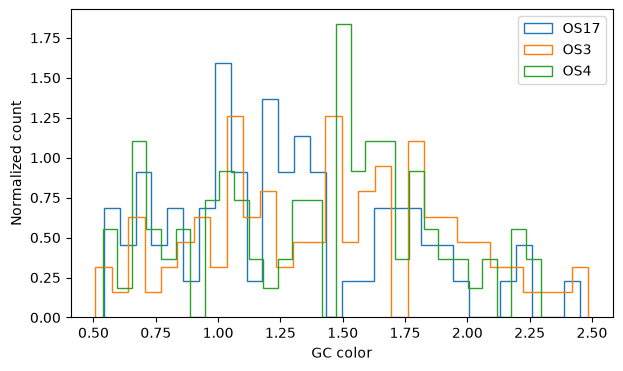

In [89]:
fig, ax = plt.subplots(figsize=(7, 4))

for pointing, group in outer_gc.groupby("pointing"):
    ax.hist(
        group[cols.gc_color],
        bins=30,
        histtype="step",
        label=pointing,
        density=True,
    )

ax.set_xlabel("GC color")
ax.set_ylabel("Normalized count")
ax.legend()

plt.show()

In [90]:
# peng_like = outer_df[
#     (outer_df[cols.gc_mag] < 26.5)
#     & (outer_df[cols.gc_color] > 0.6)
#     & (outer_df[cols.gc_color] < 1.5)
# ].copy()
peng_like = outer_df[
    (outer_df[cols.gc_mag] < 26.07)
    & (outer_df[cols.gc_color] > 1.10)
    & (outer_df[cols.gc_color] < 2.00)
].copy()

In [91]:
print(
    peng_like["pointing"]
    .value_counts()
    .sort_index()
)

print()
print("Total:", len(peng_like))


pointing
OS17    35
OS3     60
OS4     52
Name: count, dtype: int64

Total: 147


In [92]:
pblue_peng_like, _ = compute_Pblue(
    peng_like[cols.gc_mag].to_numpy(),
    peng_like[cols.gc_color].to_numpy(),
)

peng_like["Pblue"] = pblue_peng_like

print(
    peng_like.groupby("pointing")["Pblue"]
    .agg(["count", "mean", "std", "median"])
)

print()
print(
    peng_like["Pblue"]
    .agg(["count", "mean", "std", "median"])
)


          count      mean       std    median
pointing                                     
OS17         31  0.574517  0.236370  0.693289
OS3          55  0.515773  0.243062  0.563105
OS4          50  0.532274  0.235334  0.643701

count     136.000000
mean        0.535230
std         0.238035
median      0.629174
Name: Pblue, dtype: float64


##### Applying the Peng et al. magnitude and color cuts to the Madrid et al. outer-field catalog yields 136 candidates with finite $P_{\rm blue}$ values across OS3, OS4, and OS17. The field means are 0.575, 0.515, and 0.532, respectively, giving a combined mean $\langle P_{\rm blue}\rangle_{\rm fg/bg}=0.535$. Although the candidate counts remain higher than those reported by Peng et al., likely because their full morphology and quality cuts cannot be reproduced exactly, the field-to-field consistency suggests that the derived color-mixture parameter is reasonably stable.

In [44]:
PBLUE_BG = 0.535230
PBLUE_BG_GRID = [0.50, 0.54, 0.58]


Peng specifically says they masked brighter galaxies in the OS fields (see figure) - I can only see one which might apply in this respect, but it probably wasn't masked, but I doubt it would make that much difference. In fact, the brightest is a 10 mag star, but galaxies are dimmer than 15 mag (~-20 Mag) (from Aladin)

In summary, visual inspection of the three outer ACS fields confirms that they contain no obvious massive Coma galaxies whose GC systems would dominate the selected source population. Differences from the Peng et al. candidate counts are therefore more likely to arise from differences in source detection, morphology, and quality selection than from unmasked bright cluster members.

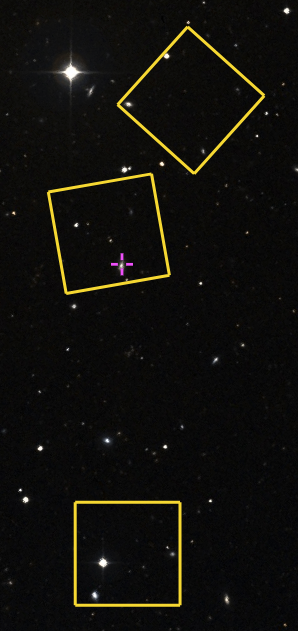

# Estimate ICGC color dispersion

Peng+2011 effectively tells us how to identify an empirical predominantly-ICGC sample:

$$ R_{4874}>130~{\rm kpc}, $$

in the unmasked core fields, with the bright color-distribution sample in Fig. 8 using $I<25$. They then establish that this population is approximately 4:1 blue:red. If those objects are represented in our data (i.e. the Madrid+2018 catalog), we can select the analogous outer population directly and simply run the actual observed colors and magnitudes through our recalibrated compute_Pblue.

That would give

$$ \langle P_{\rm blue}\rangle_{\rm ICGC} = \frac{1}{N_{\rm IGC}} \sum_i P_{{\rm blue},i} $$

without having to assume either peak width (which we don't have).

So the next step should be to construct an analogous ICGC catalog from our data.



In [48]:
data.loc[
    data["pointing"].str.contains("7", na=False),
    "pointing"
].unique()


<ArrowStringArray>
['OS17', '7-7', '2-7']
Length: 3, dtype: str

In [93]:
peng_pointings = ["1-1", "1-2", "1-3", 
                  "2-1", "2-2", "2-3", "2-5", "2-6", "2-7", 
                  "3-1", "3-2", "3-4", "3-5", 
                  "4-1", "4-2", "4-3", "4-4", 
                  "5-5",
                  "7-7",
                  # "OS3", "OS4", "OS13", "OS17", "OS21", "OS36",
                 ]  # excluding outskirt pointings

icgc_df = data[
    data["pointing"].isin(peng_pointings)
].copy()

print(
    icgc_df["pointing"]
    .value_counts()
    .sort_index()
)

pointing
1-1     311
1-2     363
1-3     298
2-2     301
2-3     448
2-5     555
2-6     439
2-7     315
3-1     289
3-2     899
3-4     607
3-5    4426
4-1     233
4-2     418
4-3     358
4-4     253
5-5     237
7-7     234
Name: count, dtype: int64


In [94]:
icgc_df = icgc_df[
    (icgc_df[cols.gc_mag] < 24.57)
].copy()


print(
    icgc_df["pointing"]
    .value_counts()
    .sort_index()
)

pointing
1-1     105
1-2      82
1-3      76
2-2      91
2-3     157
2-5     121
2-6     145
2-7      72
3-1     124
3-2     337
3-4     233
3-5    1232
4-1     106
4-2      88
4-3      63
4-4     124
5-5     105
7-7      74
Name: count, dtype: int64


In [95]:
icgc_df.columns

Index(['x_wcs', 'y_wcs', 'flux_814', 'flux_475', 'mag_814', 'mag_475', 'color',
       'pointing', 'x', 'y', 'type', 'x_wcs_f', 'y_wcs_f', 'gc_type_f',
       'pointing_f', 'Unnamed: 15', 'Pblue'],
      dtype='str')

In [96]:
print(gals_df.loc[gals_df["name"]=="NGC 4874", ["ra","dec"]])
print(gals_df.loc[gals_df["name"]=="NGC 4874", "ra"].values[0])

             ra        dec
169  194.898789  27.959248
194.89878906845


Now we need the NGC 4874 (or BCGs?) distance columns.

In [97]:
from astropy.coordinates import SkyCoord
import astropy.units as u

ngc4874_coord = SkyCoord(
    ra=gals_df.loc[gals_df["name"]=="NGC 4874", "ra"].values[0] * u.deg,
    dec=gals_df.loc[gals_df["name"]=="NGC 4874", "dec"].values[0] * u.deg,
)

css_coords = SkyCoord(
    ra=icgc_df["x_wcs"].to_numpy() * u.deg,
    dec=icgc_df["y_wcs"].to_numpy() * u.deg,
)

sep = css_coords.separation(ngc4874_coord)

icgc_df["R_4874_arcsec"] = sep.arcsec
icgc_df["R_4874_arcmin"] = sep.arcmin

Convert to kpc

In [98]:
KPC_PER_ARCSEC = 0.4848

icgc_df["R_4874_kpc"] = (
    icgc_df["R_4874_arcsec"] * KPC_PER_ARCSEC
)

Then cut on outer 130 kpc

In [99]:
icgc_outer_full = icgc_df[
    icgc_df["R_4874_kpc"] > 130
].copy()


In [100]:
print(icgc_outer_full["R_4874_kpc"].describe())
print()
print(icgc_outer_full["pointing"].value_counts().sort_index())


count    1663.000000
mean      320.391419
std       116.324048
min       130.092647
25%       214.811913
50%       318.967082
75%       416.676136
max       554.529751
Name: R_4874_kpc, dtype: float64

pointing
1-1    105
1-2     82
1-3     76
2-2     91
2-3    157
2-5     35
2-6     87
2-7     72
3-1    124
3-2    337
3-4     51
4-1    106
4-2     88
4-3     63
4-4     21
5-5     94
7-7     74
Name: count, dtype: int64


In [117]:
icgc_outer = icgc_df[
    (icgc_df["R_4874_kpc"] > 130)
    & (icgc_df[cols.gc_mag] < 24.57)
    & (icgc_df[cols.gc_color] > 1.1)
    & (icgc_df[cols.gc_color] < 2.0)
].copy()

icgc_inner = icgc_df[
    (icgc_df["R_4874_kpc"] < 50)
    & (icgc_df[cols.gc_mag] < 24.57)
    & (icgc_df[cols.gc_color] > 1.1)
    & (icgc_df[cols.gc_color] < 2.0)
].copy()


In [110]:
summary = (
    icgc_outer
    .groupby("pointing")
    .agg(
        N=("pointing", "size"),
        R_med=("R_4874_kpc", "median"),
        R_min=("R_4874_kpc", "min"),
        R_max=("R_4874_kpc", "max"),
    )
    .sort_values("R_med")
)

print(summary.to_string())

            N       R_med       R_min       R_max
pointing                                         
3-4        49  142.680515  130.339950  173.918363
4-4        20  142.868750  130.893679  163.685999
2-5        32  147.329176  130.099754  175.204897
2-6        81  150.591733  130.092647  194.636085
5-5        80  176.268931  130.826074  208.257122
4-3        55  178.794838  150.062056  247.231329
2-7        61  189.707764  146.622726  258.295517
2-3       137  261.409255  203.391239  321.002623
4-2        74  282.177642  249.768619  343.602883
1-3        56  324.958043  284.869676  399.272134
3-2       310  340.504495  253.428709  517.246900
2-2        81  349.429686  300.022893  417.397294
4-1        90  414.114128  345.543570  443.642507
7-7        69  414.588423  379.202453  483.896422
1-2        60  420.062160  362.914298  479.488931
3-1       114  424.663174  363.606449  467.303108
1-1        89  520.804304  450.901230  554.529751


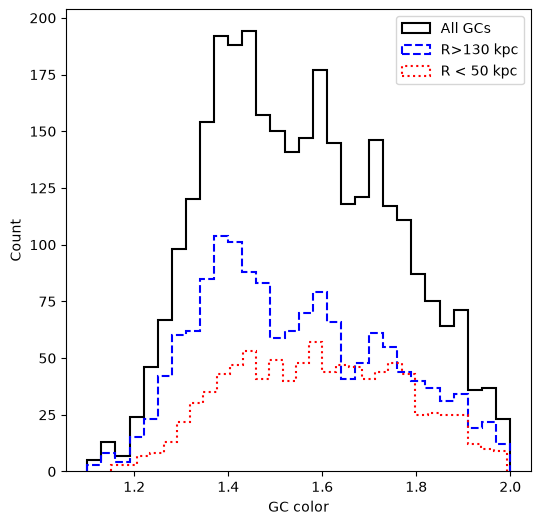

In [140]:

icgc_df_magcut = icgc_df[
    (icgc_df[cols.gc_mag] < 24.57)
    & (icgc_df[cols.gc_color] > 1.1)
    & (icgc_df[cols.gc_color] < 2.0)
].copy()

def plot_icgc_hist(df_full, df_outer, df_inner, title=None):
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    ax.hist(
        df_full[cols.gc_color],
        bins=30,
        histtype="step",
        label="All GCs",
        density=False,
        linewidth="1.5",
        color='black',
    )
    
    ax.hist(
        df_outer[cols.gc_color],
        bins=30,
        histtype="step",
        label="R>130 kpc",
        density=False,
        linestyle="--",
        linewidth="1.5",
        color="blue",
    )
    
    ax.hist(
        df_inner[cols.gc_color],
        bins=30,
        histtype="step",
        label="R < 50 kpc",
        density=False,
        linestyle=":",
        linewidth="1.5",
        color="red",)
    
    ax.set_xlabel("GC color")
    ax.set_ylabel("Count")
    ax.legend()
    
    plt.show()

plot_icgc_hist(icgc_df_magcut, icgc_outer, icgc_inner)


## Comparison with Peng figure 8

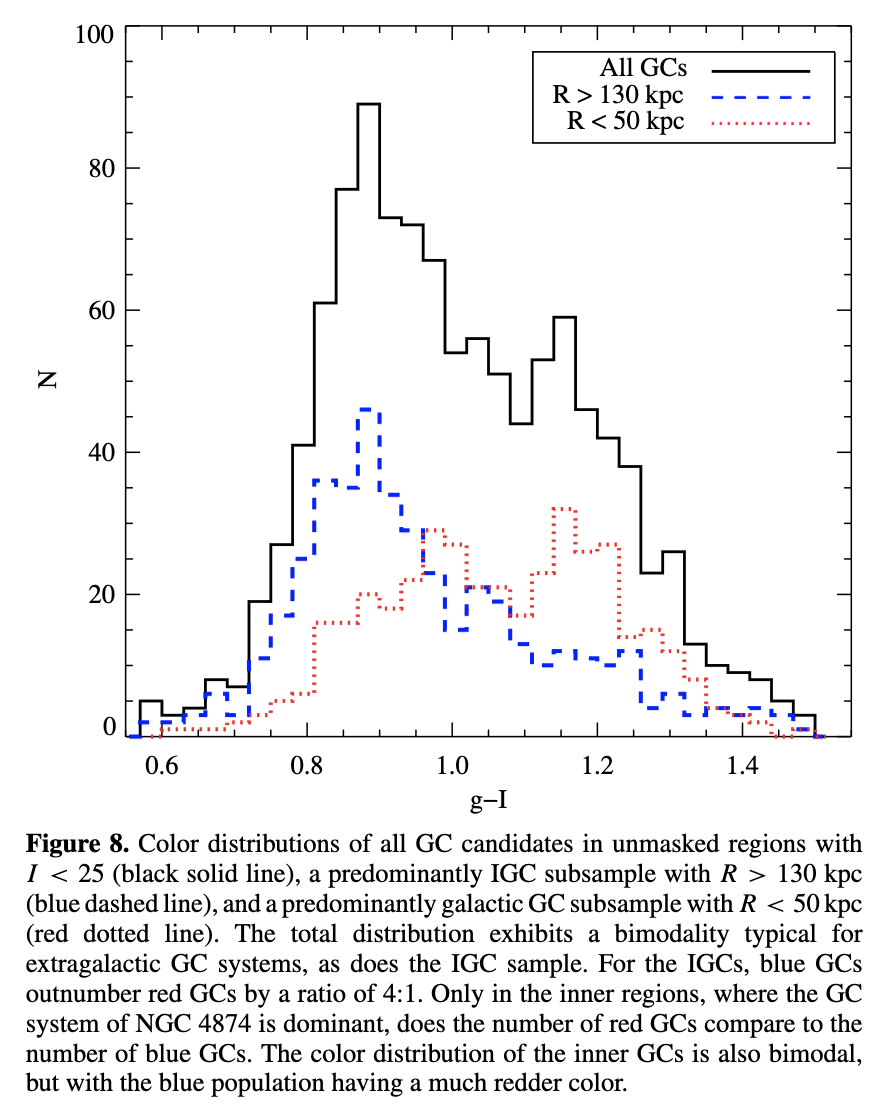
<!-- 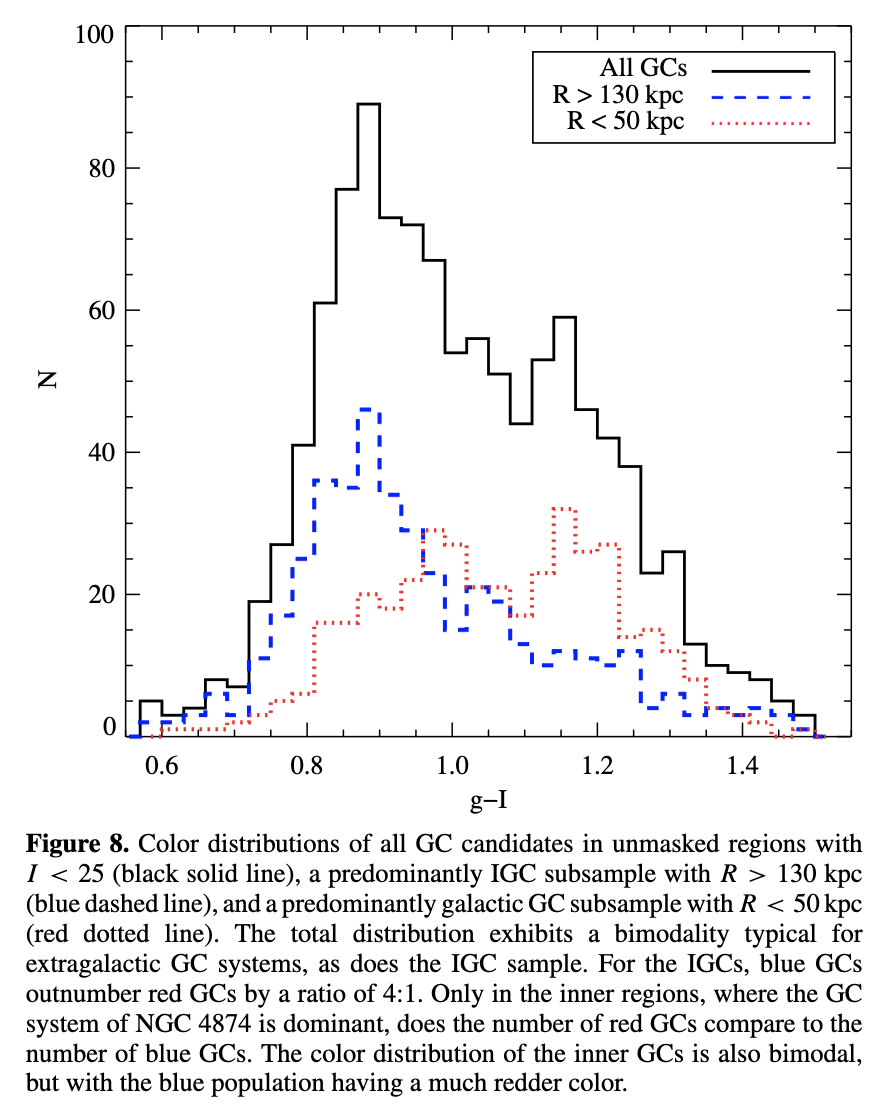 -->

In [118]:
print(icgc_outer["Pblue"].describe())


count    1294.000000
mean        0.621812
std         0.205766
min         0.039743
25%         0.531879
50%         0.717382
75%         0.773476
max         0.803949
Name: Pblue, dtype: float64


## Mask other 'bright' galaxies

In [128]:
gals_df.columns

Index(['name', 'ra', 'dec', 'otype', 'z', 'Vmag_simbad_raw', 'Bmag_simbad_raw',
       'BV_simbad_raw', 'gmag_simbad_raw', 'rmag_simbad_raw',
       'imag_simbad_raw', 'zmag_simbad_raw', 'gr_simbad_raw', 'gi_simbad_raw',
       'major_axis_arcsec', 'galdim_minaxis', 'galdim_angle', 'dim_source',
       'galdim_qual', 'galdim_bibcode', 'dim_ref', 'MV_simbad_raw',
       'show_label', 'Re_arcsec', 'otype_family', 'morph_type', 'major_kpc',
       'is_large_E', 'sdss_objid', 'Re_r_arcsec', 'Re_r_arcsec_circ',
       'g_cmodel_sdss', 'r_cmodel_sdss', 'i_cmodel_sdss', 'gerr_cmodel_sdss',
       'rerr_cmodel_sdss', 'ierr_cmodel_sdss', 'Ag_sdss', 'Ar_sdss', 'Ai_sdss',
       'g0_cmodel_sdss', 'r0_cmodel_sdss', 'i0_cmodel_sdss', 'sdss_phot_ok',
       'gr0_sdss', 'gi0_sdss', 'g_model_sdss', 'r_model_sdss', 'i_model_sdss',
       'gerr_model_sdss', 'rerr_model_sdss', 'ierr_model_sdss',
       'g0_model_sdss', 'r0_model_sdss', 'i0_model_sdss', 'Vmag_sdss',
       'Vmag_sdss_err', 'V_source', 'mV

Define galaxy subset

In [131]:
MV_CUT = -17.0
K_RE = 8.0

mask_gals = gals_df[
    np.isfinite(gals_df["Re_best_arcsec"])
    & np.isfinite(gals_df["MV_abs"])
    & (gals_df["MV_abs"] <= MV_CUT)
].copy()


In [132]:
gc_coords = SkyCoord(
    ra=icgc_outer["x_wcs"].to_numpy() * u.deg,
    dec=icgc_outer["y_wcs"].to_numpy() * u.deg,
)

gal_coords = SkyCoord(
    ra=mask_gals["ra"].to_numpy() * u.deg,
    dec=mask_gals["dec"].to_numpy() * u.deg,
)



In [133]:
inside_any_galaxy = np.zeros(len(icgc_outer), dtype=bool)

for (_, gal), gal_coord in zip(mask_gals.iterrows(), gal_coords):

    r_mask_arcsec = K_RE * gal["Re_best_arcsec"]

    sep_arcsec = gc_coords.separation(gal_coord).arcsec

    inside_any_galaxy |= (
        sep_arcsec < r_mask_arcsec
    )


In [134]:
icgc_outer["inside_galaxy_mask"] = inside_any_galaxy

icgc_masked = icgc_outer[
    ~icgc_outer["inside_galaxy_mask"]
].copy()


In [135]:
print(f"Galaxies used for masking: {len(mask_gals)}")
print(f"GCs before masking:        {len(icgc_outer)}")
print(f"GCs masked:                {inside_any_galaxy.sum()}")
print(f"GCs retained:              {len(icgc_masked)}")
print(
    f"Fraction retained:         "
    f"{len(icgc_masked)/len(icgc_outer):.3f}"
)


Galaxies used for masking: 126
GCs before masking:        1458
GCs masked:                824
GCs retained:              634
Fraction retained:         0.435


In [136]:
nearest_name = np.full(len(icgc_outer), None, dtype=object)
nearest_r_over_re = np.full(len(icgc_outer), np.inf)

for (_, gal), gal_coord in zip(mask_gals.iterrows(), gal_coords):

    sep_arcsec = gc_coords.separation(gal_coord).arcsec

    r_over_re = (
        sep_arcsec / gal["Re_best_arcsec"]
    )

    better = r_over_re < nearest_r_over_re

    nearest_r_over_re[better] = r_over_re[better]
    nearest_name[better] = gal["name"]


In [137]:
icgc_outer["nearest_galaxy"] = nearest_name
icgc_outer["R_over_Re_nearest"] = nearest_r_over_re


In [138]:
icgc_8Re = icgc_outer[
    icgc_outer["R_over_Re_nearest"] >= 8
].copy()

icgc_12Re = icgc_outer[
    icgc_outer["R_over_Re_nearest"] >= 12
].copy()


PBlue with 8Re / Mv < -17 mag masking
count    588.000000
mean       0.660152
std        0.180535
min        0.053744
25%        0.605607
50%        0.745575
75%        0.776311
max        0.803949
Name: Pblue, dtype: float64



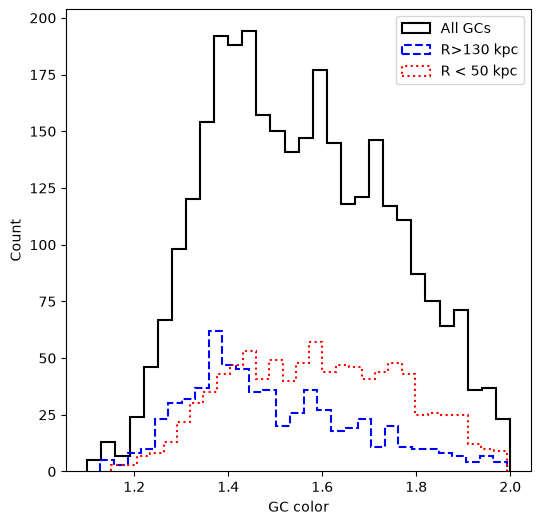

PBlue with 12Re / Mv < -17 mag masking
count    221.000000
mean       0.657903
std        0.181992
min        0.056688
25%        0.598072
50%        0.750310
75%        0.775868
max        0.803949
Name: Pblue, dtype: float64


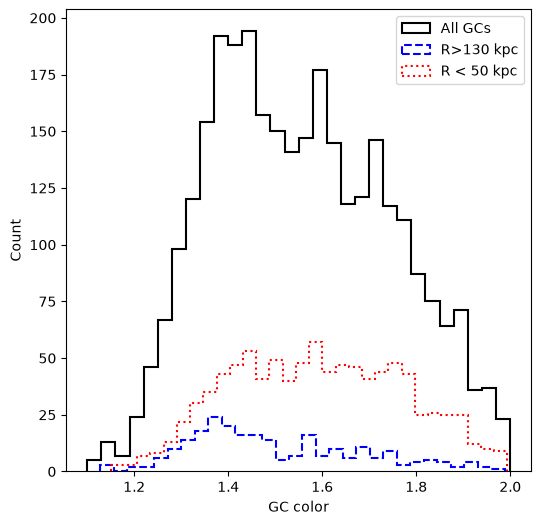

In [143]:
print("PBlue with 8Re / Mv < -17 mag masking")
print(icgc_8Re["Pblue"].describe())
print()
plot_icgc_hist(icgc_df_magcut, icgc_8Re, icgc_inner, title="ICGC with 8Re / Mv < -17 mag masking")

print("PBlue with 12Re / Mv < -17 mag masking")
print(icgc_12Re["Pblue"].describe())
plot_icgc_hist(icgc_df_magcut, icgc_12Re, icgc_inner, title="ICGC with 12Re / Mv < -17 mag masking")


The 8Re mask is doing what I hoped: it removes a substantial red-tail contribution while leaving the blue-dominated outer population intact.

The numbers make that really clear, i.e.,

$$ \langle P_{\rm blue}\rangle_{\rm ICGC} = 0.622 \quad\text{unmasked}, $$

rising to

$$ 0.660 \quad\text{with }8R_e\text{ masking}, $$

and then barely changing to

$$ 0.658 \quad\text{with }12R_e\text{ masking}. $$

That plateau between 8Re and 12Re is a key result. It says the inferred ICGC mixture is stable once obvious galaxy-associated regions are removed.

This is good to adopt now.

$$ \boxed{ \langle P_{\rm blue}\rangle_{\rm ICGC}\approx0.66 } $$

as the fiducial value, with 8Re as the preferred mask and 12Re as a robustness test.

The fact that 12Re removes more than half of the remaining sample — 588 down to 221 — but barely changes the mean is especially reassuring. It means we’re no longer tuning the value by progressively carving away galaxies. The mixture has converged.

There’s also a nice physical interpretation here: the unmasked sample contains extra red-weighted GCs from luminous galaxy systems, which depresses the mean Pblue. Once those regions are masked, the remaining outer population is more strongly blue-dominated, consistent with Peng’s qualitative 4:1 IGC result.

## Interpretation
Masking regions within 8Re of galaxies brighter than MV = -17 removes much of the red tail present in the nominal R > 130 kpc sample and raises the mean Pblue from 0.622 to 0.660. Increasing the mask to 12Re substantially reduces the number of retained candidates but changes the mean only marginally, to 0.658. The inferred ICGC color-mixture proxy is therefore stable once obvious galaxy-associated populations are excluded. We adopt the 8Re result, <Pblue>ICGC = 0.660, as the fiducial empirical ICGC value and use the 12Re mask as a sensitivity check.

So, in summary, we now have both external components expressed on the same Pblue scale:

$$ \langle P_{\rm blue}\rangle_{\rm fg/bg}\approx0.535 $$

and

$$\langle P_{\rm blue}\rangle_{\rm ICGC}\approx0.660.$$


For Peng+2011, their fitted ICGC density,

$$ \Sigma_{\rm IGC,tot}=0.055\pm0.002~{\rm kpc}^{-2}, $$

is corrected to the full GCLF. Their actual catalog cut at $I_{\rm AB}<26.5$ contains about

$$ f_{\rm GCLF}=0.39 $$

of all GCs under their adopted M87-like GCLF (see section 2.4). Therefore the density appropriate to the observed magnitude-limited catalog is

$$ \Sigma_{\rm IGC,obs} = 0.39\times0.055 = 0.02145~{\rm kpc}^{-2}. $$

At 100 Mpc, with $ 1' \simeq 29.1~{\rm kpc}$, we have $ 1~{\rm arcmin}^2\simeq846~{\rm kpc}^2$, so

$$ \boxed{ \Sigma_{\rm IGC,obs}\simeq18.1~{\rm arcmin}^{-2} } $$

for the Peng magnitude-limited sample.

The formal uncertainty from the fitted constant alone is only roughly

$$ 0.39\times0.002\times846 \simeq0.66~{\rm arcmin}^{-2}, $$

although the GCLF assumption introduces a much larger systematic uncertainty, as Peng explicitly discuss.

Now, we can check this understanding. Peng's raw contaminant density was

$$ 2.8\pm0.3~{\rm arcmin}^{-2}. $$

Their Table 1 says the contaminant density after correcting to the full GCLF is

$$ 7.2\pm1.2~{\rm arcmin}^{-2}. $$

But:

$$ \frac{2.8}{0.39}=7.18~{\rm arcmin}^{-2}. $$

which is effectively exactly their quoted 7.2, so this confirms our interpretation of the bookkeeping:

| Component | Observed, $I<26.5$ | Full-GCLF corrected |
| --- | :---: | ---: |
| fg/bg contaminants | $2.8~{\rm arcmin}^{-2}$ | $7.2~{\rm arcmin}^{-2}$ |
| ICGCs | $\sim18.1~{\rm arcmin}^{-2}$ | $0.055~{\rm kpc}^{-2}\approx46.5~{\rm arcmin}^{-2}$ |

For our candidate-level correction, we will need to use the observed (left-hand) column, not the extrapolated full-GCLF values.

Luckily, because we already translated Peng's $I_{\rm AB}<26.5$ cut to approximately $ m_{814,\rm Madrid}<26.07$ in our magnitude system, above, the pieces are all now on the same observational footing.

We therefore have a complete first-pass external model, i.e., 

For the true contaminants:

$$ \Sigma_{\rm fg/bg}=2.8\pm0.3~{\rm arcmin}^{-2}, $$ $$ \langle P_{\rm blue}\rangle_{\rm fg/bg}\simeq0.535. $$

For the diffuse ICGCs:

$$ \Sigma_{\rm IGC}\simeq18.1~{\rm arcmin}^{-2}, $$ $$ \langle P_{\rm blue}\rangle_{\rm IGC}\simeq0.660. $$

That was the aim of this exploration, and should be enough to calculate, for each aperture:

$$ N_{\rm fg/bg} = A\,\Sigma_{\rm fg/bg} $$

and

$$ N_{\rm IGC} = A\,\Sigma_{\rm IGC}, $$

with area in arcmin², and their expected blue-weighted contributions:

$$ N_{\rm blue,fg/bg}^{\rm eff} = N_{\rm fg/bg}\, \langle P_{\rm blue}\rangle_{\rm fg/bg}, $$ $$ N_{\rm blue,IGC}^{\rm eff} = N_{\rm IGC}\, \langle P_{\rm blue}\rangle_{\rm IGC}. $$

Then we can start asking what happens when we subtract only the true contaminant floor, versus contaminants + the baseline diffuse ICGC component.

> **NOTE:** $18.1~{\rm arcmin}^{-2}$ is the candidate-level normalization under Peng's adopted giant-elliptical GCLF. Their alternative dwarf-like GCLF changes the inferred total population substantially. So eventually that normalization will require a sensitivity test.

Nevertheless, we now have a very well-motivated fiducial value to work with rather than a figure plucked from literature without justification.